In [1]:
# --! include root folders into PYTHONPATH --!

import os
import sys

curr_dir = os.getcwd()
example_dir = os.path.abspath(os.path.join(curr_dir, '..'))
sys.path.append(example_dir)
root_dir = os.path.abspath(os.path.join(curr_dir, '..', '..', '..'))
sys.path.append(root_dir)

import torch
import numpy as np
from matplotlib import pyplot as plt

import example_mujoco
import util_data
import util_nn
import kind

data_dir = '../../../data/mujoco/walker2d'
model_dir = '../../../models/mujoco/walker2d'
result_dir = '../../../results/mujoco/walker2d'

In [2]:
# --! specify kind arguments

parser = kind.create_args_parser()
args = parser.parse_args(
    args=[
        '--file_dir', data_dir,
        '--file_name', 'walker2d',
        '--data_nsample_baseline', '918',
        '--data_nsample_nom', '48',
        '--data_nsample_exc', '48',
        '--obs_ndim', '17',
        '--act_ndim', '6',
        '--target_ndim', '17',
        '--data_train_size', '0.8',

        '--back_nsample', '32',
        '--fore_nsample', '16',

        '--batch_size', '256',
        '--learning_rate', '0.001',
        '--weight_decay', '0.000001',
        '--nepoch', '800',
        '--patience', '50',
        '--checkpoints', model_dir,

        '--rez_nsample_nom', '16',
        '--rez_nsample_exc', '8',
        '--embed_nom', '{"sin": 6, "cos": 6}',
        '--embed_exc', '{"data": 12}',
    ]
)

setpoint = torch.zeros(args.target_ndim)

In [3]:
# --! initialize random seed

seeds = [3, 123, 2026, 8192, 65536]
seed = seeds[0]

util_nn.set_seed(seed)

print(f'setting seed {seed}')

setting seed 3


In [4]:
# --! create model, dataset and training

model = kind.model(args)
dataset = example_mujoco.dataset(args, setpoint, load_normalized=True, extract_windows=False)
training = kind.training(model)

In [5]:
# --! compute model capacity

nparam = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'number of trainable parameters: {nparam/1e6}M')

number of trainable parameters: 1.849036M


### Train nominal model

In [6]:
model.train()
training.fit(dataset)

>>> training nominal mean >>>
	epoch 1 losses: train=0.681099, valid=0.320328, test=0.323695
	validation loss decreased (inf -> 0.320328), saving model ...
	epoch 2 losses: train=0.214805, valid=0.172858, test=0.175238
	validation loss decreased (0.320328 -> 0.172858), saving model ...
	epoch 3 losses: train=0.150717, valid=0.134403, test=0.136559
	validation loss decreased (0.172858 -> 0.134403), saving model ...
	epoch 4 losses: train=0.119651, valid=0.108239, test=0.110298
	validation loss decreased (0.134403 -> 0.108239), saving model ...
	epoch 5 losses: train=0.098096, valid=0.090814, test=0.092238
	validation loss decreased (0.108239 -> 0.090814), saving model ...
	epoch 6 losses: train=0.084120, valid=0.079500, test=0.080544
	validation loss decreased (0.090814 -> 0.079500), saving model ...
	epoch 7 losses: train=0.074967, valid=0.072586, test=0.073626
	validation loss decreased (0.079500 -> 0.072586), saving model ...
	epoch 8 losses: train=0.068821, valid=0.066988, test=0.06

In [8]:
model.eval()
data_loader, _, _ = dataset.load(data_type='nom')

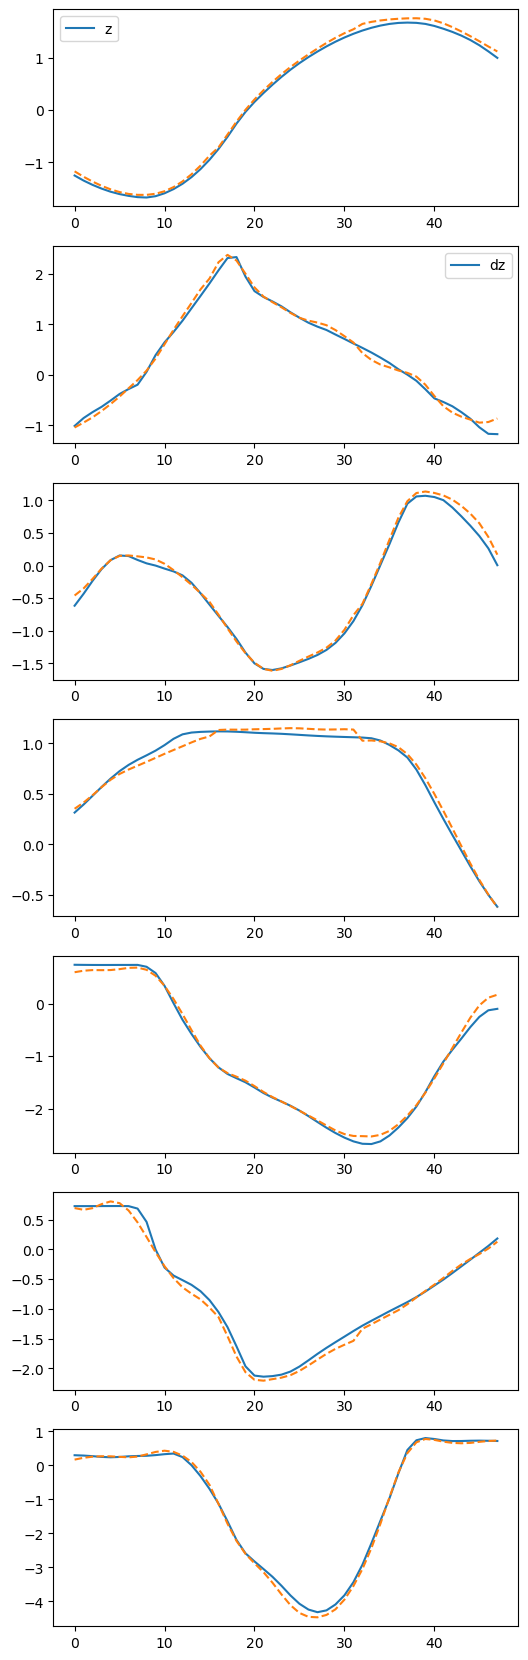

In [9]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        true = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_nom = model_o.mean_nom

        plt.figure(figsize=(6,21))

        plt.subplot(7,1,1)
        plt.plot(true[jdata, :, 0], label='z')
        plt.plot(mean_nom[0, :, 0], linestyle='dashed')
        plt.legend()

        plt.subplot(7,1,2)
        plt.plot(true[jdata, :, 9], label='dz')
        plt.plot(mean_nom[0, :, 9], linestyle='dashed')
        plt.legend()

        plt.subplot(7,1,3)
        plt.plot(true[jdata, :, 1])
        plt.plot(mean_nom[0, :, 1], linestyle='dashed')

        plt.subplot(7,1,4)
        plt.plot(true[jdata, :, 2])
        plt.plot(mean_nom[0, :, 2], linestyle='dashed')

        plt.subplot(7,1,5)
        plt.plot(true[jdata, :, 3])
        plt.plot(mean_nom[0, :, 3], linestyle='dashed')

        plt.subplot(7,1,6)
        plt.plot(true[jdata, :, 4])
        plt.plot(mean_nom[0, :, 4], linestyle='dashed')

        plt.subplot(7,1,7)
        plt.plot(true[jdata, :, 5])
        plt.plot(mean_nom[0, :, 5], linestyle='dashed')

        plt.show()

        break

### Training nominal uncertainty

In [10]:
# --! switch to next training phase - nominal uncertainty - and train
model.train()
training.fit_next()
training.fit(dataset)

>>> training nominal uncertainty >>>
	epoch 1 losses: train=0.107067, valid=0.083179, test=0.084841
	validation loss decreased (inf -> 0.083179), saving model ...
	epoch 2 losses: train=0.074326, valid=0.065725, test=0.067043
	validation loss decreased (0.083179 -> 0.065725), saving model ...
	epoch 3 losses: train=0.061716, valid=0.056605, test=0.057378
	validation loss decreased (0.065725 -> 0.056605), saving model ...
	epoch 4 losses: train=0.054158, valid=0.050955, test=0.051626
	validation loss decreased (0.056605 -> 0.050955), saving model ...
	epoch 5 losses: train=0.049135, valid=0.047172, test=0.047834
	validation loss decreased (0.050955 -> 0.047172), saving model ...
	epoch 6 losses: train=0.045842, valid=0.044335, test=0.044935
	validation loss decreased (0.047172 -> 0.044335), saving model ...
	epoch 7 losses: train=0.043498, valid=0.042251, test=0.042970
	validation loss decreased (0.044335 -> 0.042251), saving model ...
	epoch 8 losses: train=0.041926, valid=0.041164, te

In [11]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

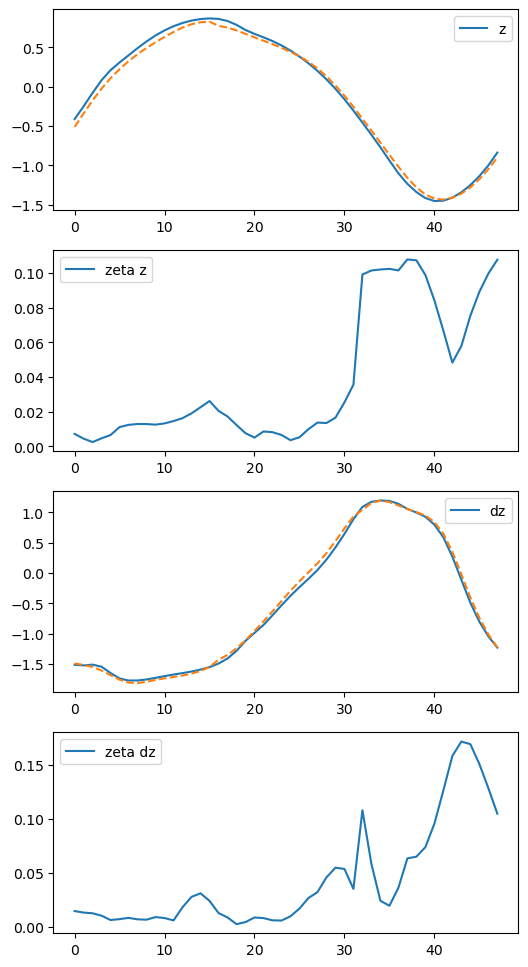

In [14]:
jdata = 2

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_nom = model_o.mean_nom
        zeta_nom = model_o.zeta_nom

        plt.figure(figsize=(6,12))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, :1], label='z')
        plt.plot(mean_nom[0, :, :1], linestyle='dashed')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(zeta_nom[0, :, :1], label='zeta z')
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(truth[jdata, :, 6], label='dz')
        plt.plot(mean_nom[0, :, 6], linestyle='dashed')
        plt.legend()

        plt.subplot(4,1,4)
        plt.plot(zeta_nom[0, :, 6], label='zeta dz')
        plt.legend()

        plt.show()

        break

### Training excursion model

In [15]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion mean >>>
	epoch 1 losses: train=0.775783, valid=0.494136, test=0.496786
	validation loss decreased (inf -> 0.494136), saving model ...
	epoch 2 losses: train=0.349927, valid=0.226029, test=0.227826
	validation loss decreased (0.494136 -> 0.226029), saving model ...
	epoch 3 losses: train=0.199171, valid=0.167156, test=0.168508
	validation loss decreased (0.226029 -> 0.167156), saving model ...
	epoch 4 losses: train=0.154047, valid=0.135216, test=0.135973
	validation loss decreased (0.167156 -> 0.135216), saving model ...
	epoch 5 losses: train=0.128285, valid=0.113692, test=0.114508
	validation loss decreased (0.135216 -> 0.113692), saving model ...
	epoch 6 losses: train=0.108932, valid=0.096738, test=0.097348
	validation loss decreased (0.113692 -> 0.096738), saving model ...
	epoch 7 losses: train=0.094949, valid=0.085791, test=0.086047
	validation loss decreased (0.096738 -> 0.085791), saving model ...
	epoch 8 losses: train=0.084504, valid=0.078692, test=0.

In [16]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

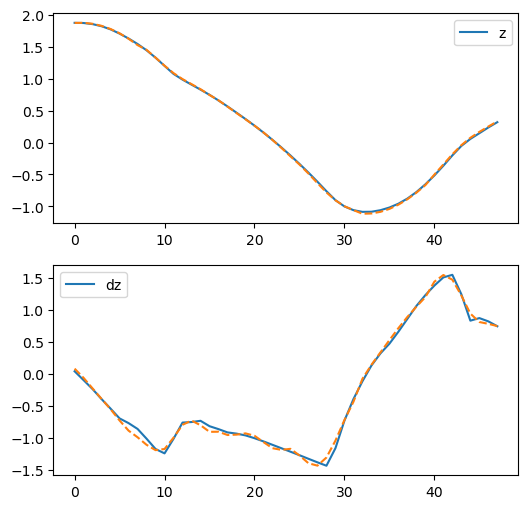

In [17]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_exc = model_o.mean_exc

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :1], label='z')
        plt.plot(mean_exc[0, :, :1], linestyle='dashed')
        plt.legend()

        plt.subplot(2,1,2)
        plt.plot(truth[jdata, :, 9], label='dz')
        plt.plot(mean_exc[0, :, 9], linestyle='dashed')
        plt.legend()

        plt.show()

        break

### Training excursion uncertainty

In [18]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion uncertainty >>>
	epoch 1 losses: train=0.227634, valid=0.169162, test=0.174643
	validation loss decreased (inf -> 0.169162), saving model ...
	epoch 2 losses: train=0.127733, valid=0.108065, test=0.110198
	validation loss decreased (0.169162 -> 0.108065), saving model ...
	epoch 3 losses: train=0.104627, valid=0.100303, test=0.102259
	validation loss decreased (0.108065 -> 0.100303), saving model ...
	epoch 4 losses: train=0.097480, valid=0.093783, test=0.095247
	validation loss decreased (0.100303 -> 0.093783), saving model ...
	epoch 5 losses: train=0.089850, valid=0.085905, test=0.087008
	validation loss decreased (0.093783 -> 0.085905), saving model ...
	epoch 6 losses: train=0.083564, valid=0.081117, test=0.082026
	validation loss decreased (0.085905 -> 0.081117), saving model ...
	epoch 7 losses: train=0.079000, valid=0.078850, test=0.079578
	validation loss decreased (0.081117 -> 0.078850), saving model ...
	epoch 8 losses: train=0.075103, valid=0.072445, 

In [19]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

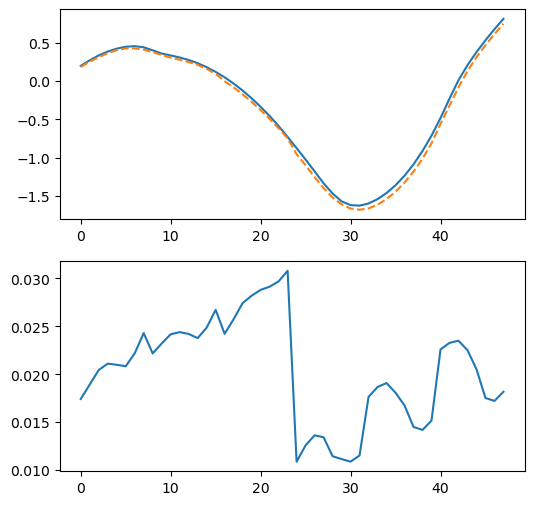

In [21]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        true = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_exc = model_o.mean_exc
        zeta_exc = model_o.zeta_exc

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(true[jdata, :, :1])
        plt.plot(mean_exc[0, :, :1], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(zeta_exc[0, :, :1])

        plt.show()

        break

### Evaluating KIND blending

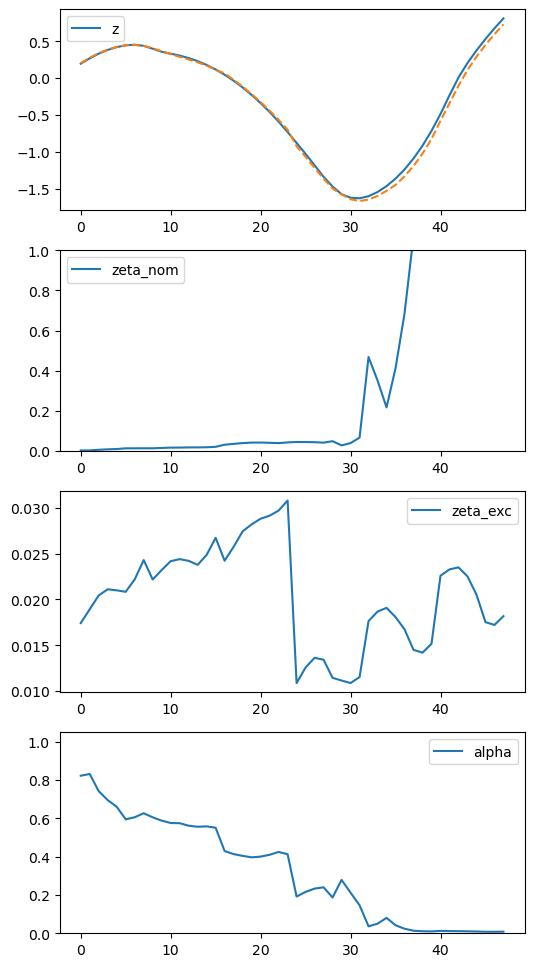

In [23]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        pred = model_o.blend
        zeta_nom = model_o.zeta_nom
        zeta_exc = model_o.zeta_exc
        alpha = model_o.alpha

        plt.figure(figsize=(6,12))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, :1], label='z')
        plt.plot(pred[0, :, :1], linestyle='dashed')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(zeta_nom[0, :, :1], label='zeta_nom')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(zeta_exc[0, :, :1], label='zeta_exc')
        plt.legend()

        plt.subplot(4,1,4)
        plt.plot(alpha[0, :, :1], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break